# Formula 1 Pit Stop Prediction

**Playground Series — Pit Stop Prediction**

The goal of this competition is to predict whether a Formula 1 driver will pit on the **next lap** (`PitNextLap`, binary 0/1), given the current lap's race state (driver, compound, lap number, tyre life, position, lap time, etc.).

**Notebook outline**
1. Importing libraries
2. Loading the data
3. Dataset information (`info`)
4. Statistical summary (`describe`)
5. Missing-value check
6. Exploratory Data Analysis
7. Feature Engineering
8. Modeling — LightGBM Baseline

## 1. Importing Libraries

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             f1_score, classification_report, confusion_matrix)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

RANDOM_STATE = 42

## 2. Loading the Data

In [129]:
train_df = pd.read_csv('../data/train.csv')
test_df = pd.read_csv('../data/test.csv')
sample_submission = pd.read_csv('../data/sample_submission.csv')

print(f'Train shape: {train_df.shape}')
print(f'Test shape : {test_df.shape}')
print(f'Sample sub : {sample_submission.shape}')

Train shape: (439140, 16)
Test shape : (188165, 15)
Sample sub : (188165, 2)


*Train has ~439K lap-level rows and test has ~188K rows (~70/30 split). Each row in `sample_submission` corresponds to a single test `id` and the column we must fill is `PitNextLap`.*

In [130]:
train_df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


*Each row represents a single lap for a given driver in a given race, with tyre/lap-time features and the target `PitNextLap` indicating whether the driver pits on the following lap.*

In [131]:
test_df.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


*The test set has the same schema as the train set minus the target. Note that the categorical `PitStop` column is still present in test — it indicates whether the driver pitted on the **current** lap (a feature, not the target).*

In [132]:
sample_submission.head()

,id,PitNextLap
0,439140,0
1,439141,0
2,439142,0
3,439143,0
4,439144,0


*Submission format is straightforward: two columns, `id` and `PitNextLap` (0 or 1).*

## 3. Dataset Information

In [133]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  str    
 2   Compound                439140 non-null  str    
 3   Race                    439140 non-null  str    
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change         439140 

*Train has 16 columns: 3 categorical (`Driver`, `Compound`, `Race`), 6 integer, and 7 float features (including the target). All columns are fully populated — no nulls.*

In [134]:
test_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188165 entries, 0 to 188164
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      188165 non-null  int64  
 1   Driver                  188165 non-null  str    
 2   Compound                188165 non-null  str    
 3   Race                    188165 non-null  str    
 4   Year                    188165 non-null  int64  
 5   PitStop                 188165 non-null  int64  
 6   LapNumber               188165 non-null  int64  
 7   Stint                   188165 non-null  int64  
 8   TyreLife                188165 non-null  float64
 9   Position                188165 non-null  int64  
 10  LapTime (s)             188165 non-null  float64
 11  LapTime_Delta           188165 non-null  float64
 12  Cumulative_Degradation  188165 non-null  float64
 13  RaceProgress            188165 non-null  float64
 14  Position_Change         188165 

*Test has 15 columns (same as train, minus `PitNextLap`) and is also free of missing values, so no imputation will be required.*

## 4. Statistical Summary

In [135]:
train_df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,219569.500000,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,126768.942943,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,0.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,109784.750000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,219569.500000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,329354.250000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,439139.000000,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


*The data spans seasons 2022–2025. The target `PitNextLap` has a mean of ~0.20, indicating a clearly **imbalanced** problem (≈80% no-pit / 20% pit). `LapTime_Delta` and `Cumulative_Degradation` show wide ranges with negative values, suggesting they are deltas relative to a baseline lap.*

In [136]:
train_df.describe(include='object')

,Driver,Compound,Race
count,439140,439140,439140
unique,887,5,26
top,MAS,MEDIUM,Dutch Grand Prix
freq,1682,211141,24462


*There are 887 unique driver IDs (very high cardinality — likely synthetic/anonymised IDs alongside real codes), 5 tyre compounds, and 26 distinct races. We'll need a careful encoding strategy for `Driver` later.*

In [137]:
test_df.describe()

,id,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
count,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000,188165.000000
mean,533222.000000,2023.528440,0.136263,23.050185,1.784237,14.160625,9.604539,90.986869,-3.577802,-25.849491,0.336695,0.106800
std,54318.701038,1.025376,0.343069,17.002292,0.948800,9.852778,5.273444,20.855248,40.348466,54.920269,0.253396,4.020592
min,439140.000000,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.017000,-2403.216000,-274.564000,0.012821,-18.000000
25%,486181.000000,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.634000,-8.874000,-46.814000,0.128205,-1.000000
50%,533222.000000,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.485000,-0.285000,-21.027000,0.269231,0.000000
75%,580263.000000,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.485000,0.122000,-6.188000,0.512821,2.000000
max,627304.000000,2025.000000,1.000000,77.000000,8.000000,77.000000,20.000000,2497.905000,2433.472000,2406.800000,1.000000,18.000000


*Test feature distributions look broadly aligned with train (similar means and ranges across years, lap numbers, and tyre life), suggesting no obvious distribution shift between the two sets.*

## 5. Missing-Value Check

In [138]:
train_nulls = train_df.isnull().sum()
train_nulls[train_nulls > 0] if train_nulls.sum() > 0 else 'No missing values in train.'

'No missing values in train.'

*Train set contains zero missing values across all 16 columns, so no imputation is needed for training.*

In [139]:
test_nulls = test_df.isnull().sum()
test_nulls[test_nulls > 0] if test_nulls.sum() > 0 else 'No missing values in test.'

'No missing values in test.'

*Test set is also clean — no missing values. We can safely move on to EDA without any imputation step.*

## 6. Exploratory Data Analysis

We now explore feature distributions and their relationships with the target. The aim is to surface the strongest signals for `PitNextLap` and flag any data oddities that should shape modeling decisions.

### 6.1 Target Distribution

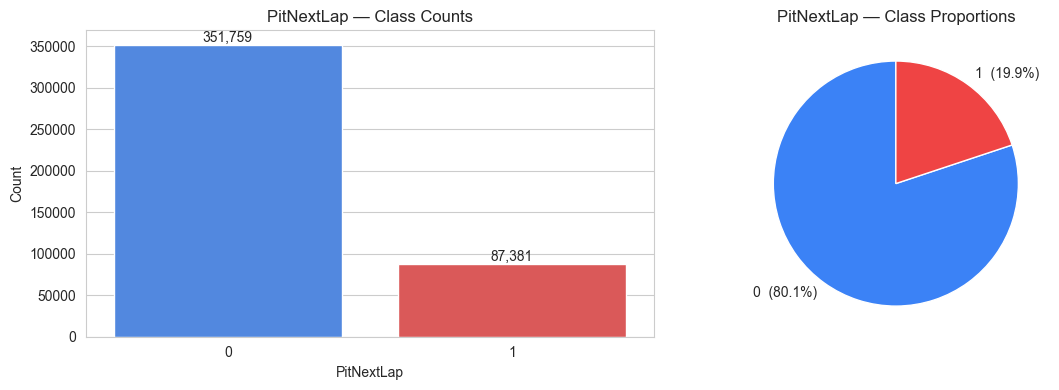

In [140]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

counts = train_df['PitNextLap'].value_counts().sort_index()
sns.barplot(x=counts.index.astype(int), y=counts.values, ax=ax[0],
            palette=['#3b82f6', '#ef4444'])
ax[0].set_title('PitNextLap — Class Counts')
ax[0].set_xlabel('PitNextLap')
ax[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax[0].text(i, v, f'{v:,}', ha='center', va='bottom')

pct = counts / counts.sum() * 100
ax[1].pie(pct, labels=[f'{int(c)}  ({p:.1f}%)' for c, p in zip(counts.index, pct)],
          colors=['#3b82f6', '#ef4444'], startangle=90,
          wedgeprops={'edgecolor': 'white'})
ax[1].set_title('PitNextLap — Class Proportions')

plt.tight_layout()
plt.show()

*The target is imbalanced: only ~20% of laps are followed by a pit stop. We'll need to track an appropriate metric (likely ROC-AUC / PR-AUC or F1) and consider class weighting or threshold tuning later.*

### 6.2 Numerical Feature Distributions

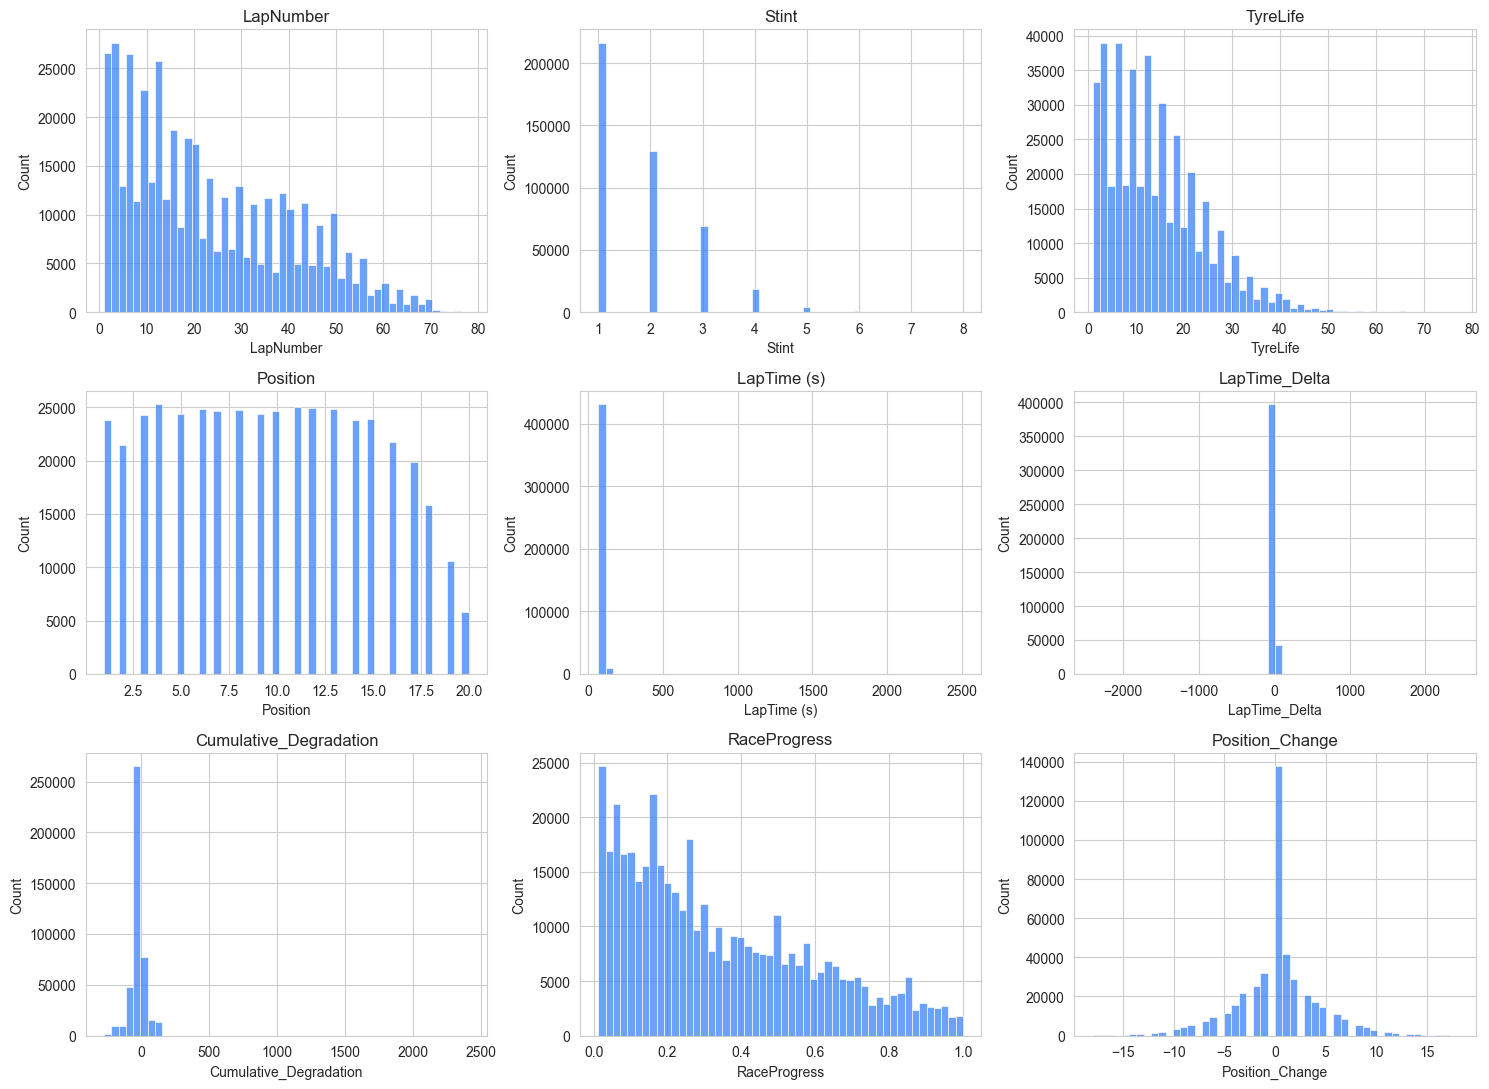

In [141]:
num_cols = ['LapNumber', 'Stint', 'TyreLife', 'Position',
            'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
            'RaceProgress', 'Position_Change']

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flatten(), num_cols):
    sns.histplot(train_df[col], bins=50, ax=ax, color='#3b82f6')
    ax.set_title(col)
plt.tight_layout()
plt.show()

*`LapNumber`, `TyreLife`, and `Stint` are right-skewed — most laps occur early in stints with relatively fresh tyres. `LapTime_Delta` and `Cumulative_Degradation` cluster around 0 with heavy tails, while `LapTime (s)` shows the expected multi-modal shape (different tracks have different lap-time scales).*

### 6.3 Lap Counts and Pit Rate by Year

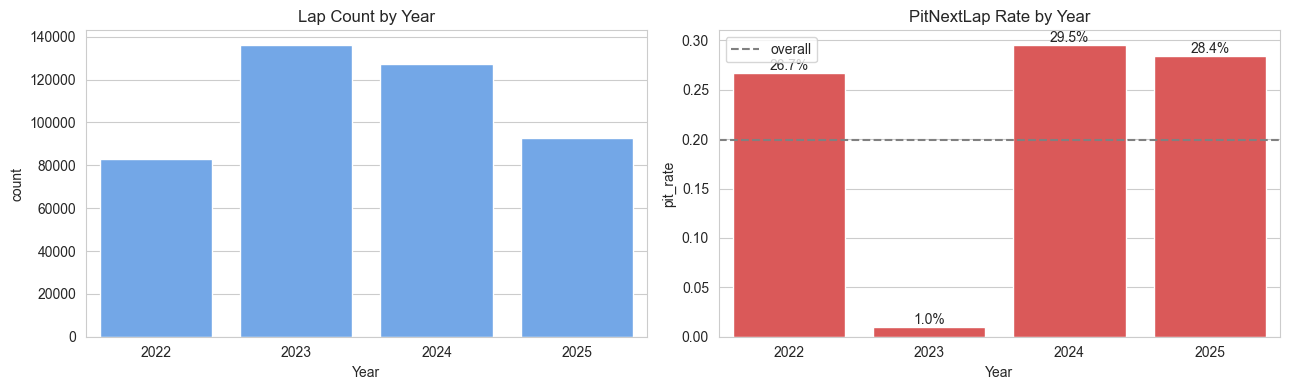

In [142]:
year_stats = (train_df.groupby('Year')
              .agg(count=('PitNextLap', 'size'),
                   pit_rate=('PitNextLap', 'mean'))
              .reset_index())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=year_stats, x='Year', y='count', ax=ax[0], color='#60a5fa')
ax[0].set_title('Lap Count by Year')

sns.barplot(data=year_stats, x='Year', y='pit_rate', ax=ax[1], color='#ef4444')
ax[1].axhline(train_df['PitNextLap'].mean(), color='gray', ls='--', label='overall')
ax[1].set_title('PitNextLap Rate by Year')
ax[1].legend()
for i, r in enumerate(year_stats['pit_rate']):
    ax[1].text(i, r, f'{r:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

*Striking finding: the **2023 season has a pit rate of just ~1%** versus ~27–30% for 2022/2024/2025. This points to either heavy synthetic augmentation for 2023 or a different sampling/labelling regime — a strong candidate for a `Year`-aware feature or a stratified validation split during modeling.*

### 6.4 Lap Counts and Pit Rate by Compound

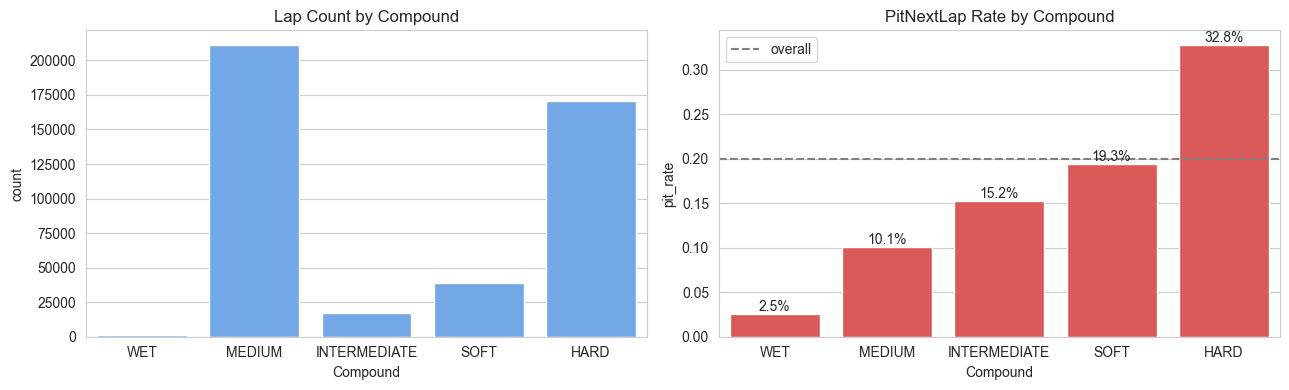

In [143]:
comp_stats = (train_df.groupby('Compound')
              .agg(count=('PitNextLap', 'size'),
                   pit_rate=('PitNextLap', 'mean'))
              .reset_index().sort_values('pit_rate'))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=comp_stats, x='Compound', y='count', ax=ax[0], color='#60a5fa')
ax[0].set_title('Lap Count by Compound')

sns.barplot(data=comp_stats, x='Compound', y='pit_rate', ax=ax[1], color='#ef4444')
ax[1].axhline(train_df['PitNextLap'].mean(), color='gray', ls='--', label='overall')
ax[1].set_title('PitNextLap Rate by Compound')
ax[1].legend()
for i, r in enumerate(comp_stats['pit_rate']):
    ax[1].text(i, r, f'{r:.1%}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

*HARD compound dominates the data (~170K laps) and has the highest pit rate (~33%) — hard tyres run longer stints and are pushed to higher tyre life before being changed. WET (1.4K laps) and INTERMEDIATE rarely pit on the next lap. Compound is clearly informative.*

### 6.5 Pit Rate by Race

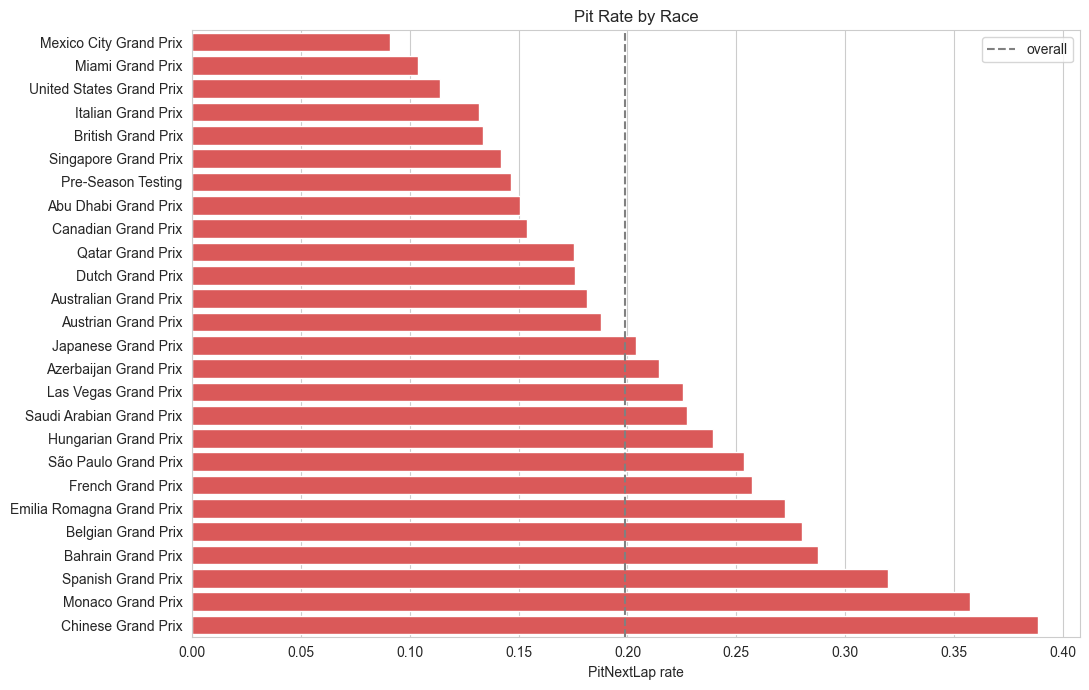

In [144]:
race_rate = train_df.groupby('Race')['PitNextLap'].mean().sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
sns.barplot(x=race_rate.values, y=race_rate.index, color='#ef4444', ax=ax)
ax.axvline(train_df['PitNextLap'].mean(), color='gray', ls='--', label='overall')
ax.set_xlabel('PitNextLap rate')
ax.set_ylabel('')
ax.set_title('Pit Rate by Race')
ax.legend()
plt.tight_layout()
plt.show()

*Pit rate varies meaningfully across circuits — Chinese GP, Monaco, and Spain see the highest rates (~32–39%), while Mexico City and Miami sit at the low end (~9–10%). This reflects circuit-specific strategy (tyre wear, safety-car likelihood, pit-loss times) and makes `Race` a useful categorical feature.*

### 6.6 Driver Cardinality

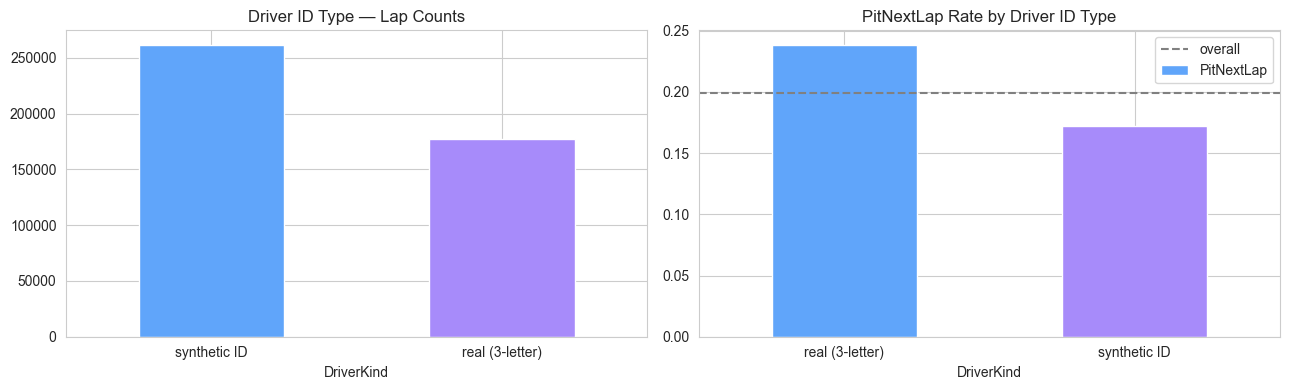

Real-style 3-letter codes : 177,516  (131 unique)
Synthetic IDs             : 261,624  (756 unique)


In [145]:
real_mask = train_df['Driver'].str.match(r'^[A-Z]{3}$')
driver_kind = pd.Series(np.where(real_mask, 'real (3-letter)', 'synthetic ID'),
                        index=train_df.index, name='DriverKind')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
driver_kind.value_counts().plot.bar(ax=ax[0], color=['#60a5fa', '#a78bfa'])
ax[0].set_title('Driver ID Type — Lap Counts')
ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=0)

pit_by_kind = train_df.groupby(driver_kind)['PitNextLap'].mean()
pit_by_kind.plot.bar(ax=ax[1], color=['#60a5fa', '#a78bfa'])
ax[1].axhline(train_df['PitNextLap'].mean(), color='gray', ls='--', label='overall')
ax[1].set_title('PitNextLap Rate by Driver ID Type')
ax[1].set_xticklabels(ax[1].get_xticklabels(), rotation=0)
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"Real-style 3-letter codes : {real_mask.sum():>7,}  ({train_df.loc[real_mask, 'Driver'].nunique()} unique)")
print(f"Synthetic IDs             : {(~real_mask).sum():>7,}  ({train_df.loc[~real_mask, 'Driver'].nunique()} unique)")

*`Driver` splits cleanly into 131 real-style 3-letter codes (~40% of laps) and 756 synthetic IDs (~60%). Pit rates differ slightly between the two groups. Given the high cardinality, target-encoding `Driver` will be more practical than one-hot encoding it.*

### 6.7 TyreLife — Distribution and Pit Rate

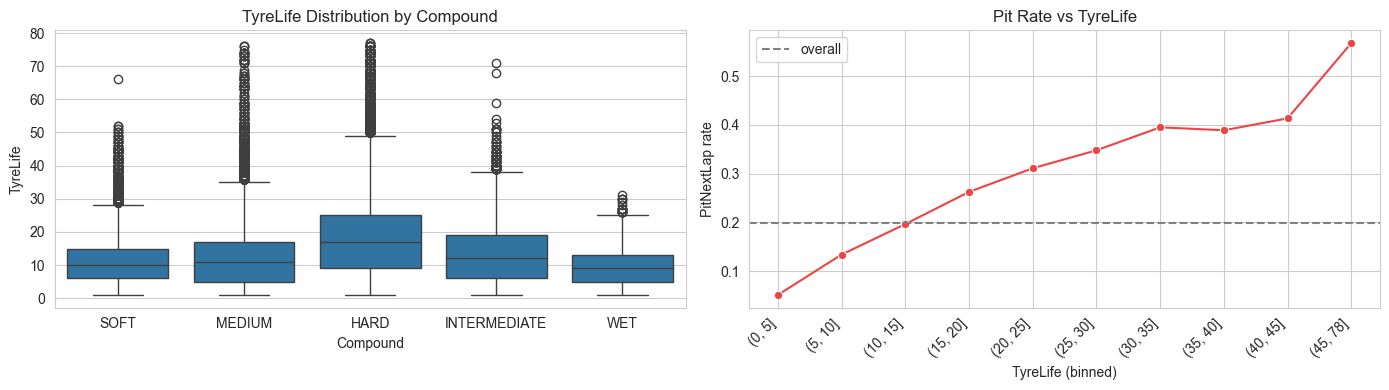

In [146]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

sns.boxplot(data=train_df, x='Compound', y='TyreLife', ax=ax[0],
            order=['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET'])
ax[0].set_title('TyreLife Distribution by Compound')

tl_bins = list(range(0, 50, 5)) + [int(train_df['TyreLife'].max()) + 1]
tl_bin_series = pd.cut(train_df['TyreLife'], bins=tl_bins)
tl_rate = train_df.groupby(tl_bin_series)['PitNextLap'].mean()
tl_rate.index = tl_rate.index.astype(str)

sns.lineplot(x=range(len(tl_rate)), y=tl_rate.values,
             marker='o', color='#ef4444', ax=ax[1])
ax[1].set_xticks(range(len(tl_rate)))
ax[1].set_xticklabels(tl_rate.index, rotation=45, ha='right')
ax[1].axhline(train_df['PitNextLap'].mean(), color='gray', ls='--', label='overall')
ax[1].set_xlabel('TyreLife (binned)')
ax[1].set_ylabel('PitNextLap rate')
ax[1].set_title('Pit Rate vs TyreLife')
ax[1].legend()

plt.tight_layout()
plt.show()

*HARD tyres run longest while SOFTs are short — exactly as expected. Crucially, **pit rate climbs almost monotonically with `TyreLife`**, peaking around 40+ laps of tyre wear. This is the strongest single feature so far and matches racing intuition (older tyres pit more).*

### 6.8 Pit Rate vs Race Progress

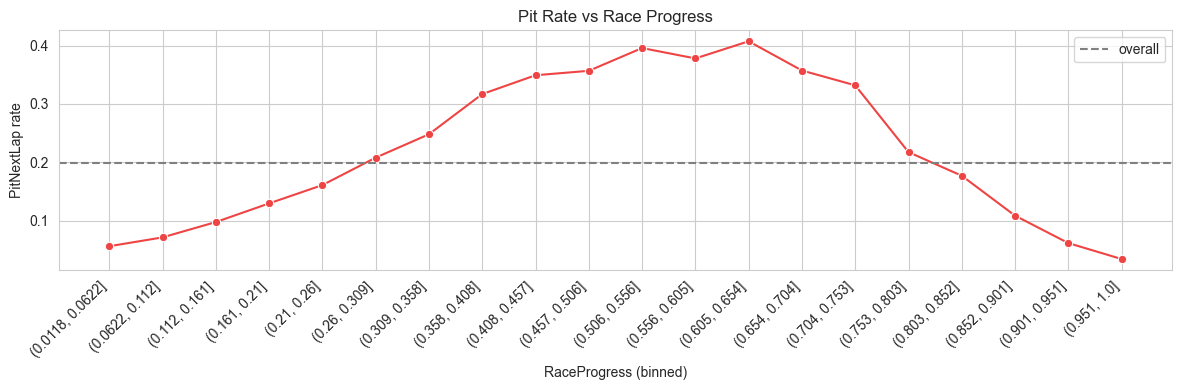

In [147]:
rp_bin_series = pd.cut(train_df['RaceProgress'], bins=20)
rp_rate = train_df.groupby(rp_bin_series)['PitNextLap'].mean()
rp_rate.index = rp_rate.index.astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(x=range(len(rp_rate)), y=rp_rate.values,
             marker='o', color='#ef4444', ax=ax)
ax.set_xticks(range(len(rp_rate)))
ax.set_xticklabels(rp_rate.index, rotation=45, ha='right')
ax.axhline(train_df['PitNextLap'].mean(), color='gray', ls='--', label='overall')
ax.set_xlabel('RaceProgress (binned)')
ax.set_ylabel('PitNextLap rate')
ax.set_title('Pit Rate vs Race Progress')
ax.legend()
plt.tight_layout()
plt.show()

*Pit rate is highest in the early/mid race window (typical pit-window region) and drops off near the finish — drivers committed to the line don't pit again. The non-linear shape will be captured well by tree-based models.*

### 6.9 Pit Rate by Stint and Position

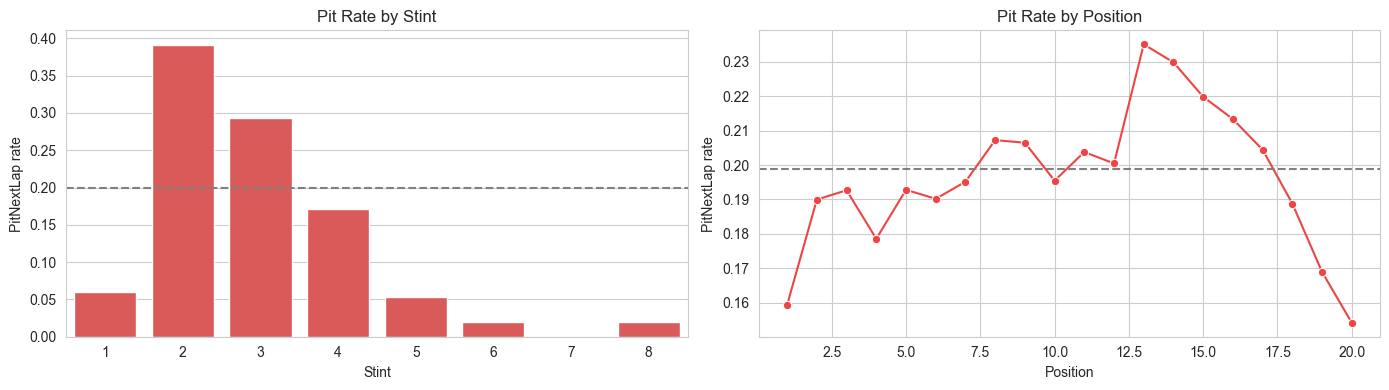

In [148]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

stint_rate = (train_df.groupby('Stint')['PitNextLap']
              .agg(['mean', 'size']).reset_index())
sns.barplot(data=stint_rate, x='Stint', y='mean', ax=ax[0], color='#ef4444')
ax[0].axhline(train_df['PitNextLap'].mean(), color='gray', ls='--')
ax[0].set_ylabel('PitNextLap rate')
ax[0].set_title('Pit Rate by Stint')

pos_rate = train_df.groupby('Position')['PitNextLap'].mean()
sns.lineplot(x=pos_rate.index, y=pos_rate.values,
             marker='o', color='#ef4444', ax=ax[1])
ax[1].axhline(train_df['PitNextLap'].mean(), color='gray', ls='--')
ax[1].set_xlabel('Position')
ax[1].set_ylabel('PitNextLap rate')
ax[1].set_title('Pit Rate by Position')

plt.tight_layout()
plt.show()

*Earlier stints (1, 2) pit far more frequently than later ones — by stint 4–5 drivers are usually on their final set. Pit rate by `Position` is fairly flat with mild variation, so position is a weaker signal than tyre/stint state.*

### 6.10 Lap-Time, Delta and Degradation by Class

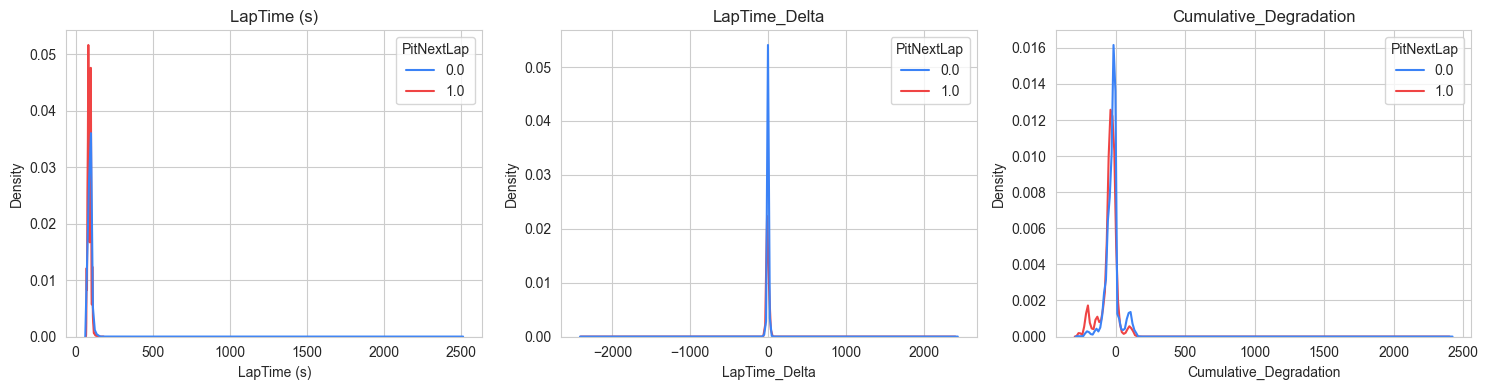

In [149]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for a, col in zip(ax, ['LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation']):
    sns.kdeplot(data=train_df, x=col, hue='PitNextLap', ax=a,
                palette=['#3b82f6', '#ef4444'], common_norm=False)
    a.set_title(col)
plt.tight_layout()
plt.show()

*The lap-time, delta and degradation distributions overlap substantially between pit/no-pit classes — these are noisy individually, but combined with `TyreLife` and `Compound` they should add useful signal to a tree model.*

### 6.11 PitStop (current lap) vs PitNextLap

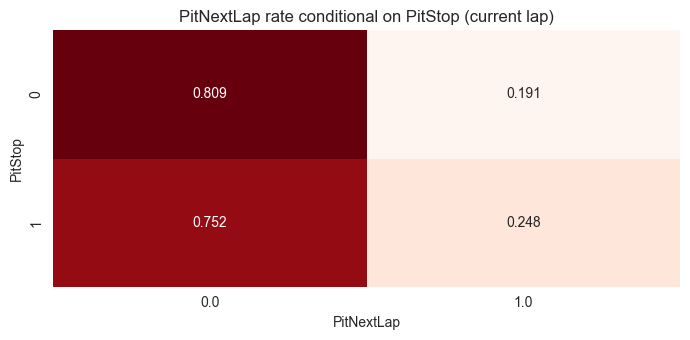

           size      mean
PitStop                  
0        379365  0.191285
1         59775  0.247829


In [150]:
ct = pd.crosstab(train_df['PitStop'], train_df['PitNextLap'], normalize='index')

fig, ax = plt.subplots(figsize=(7, 3.5))
sns.heatmap(ct, annot=True, fmt='.3f', cmap='Reds', ax=ax, cbar=False)
ax.set_title('PitNextLap rate conditional on PitStop (current lap)')
plt.tight_layout()
plt.show()

print(train_df.groupby('PitStop')['PitNextLap'].agg(['size', 'mean']))

*The current-lap `PitStop` indicator is **not a leak** — pit rate is 19% when not pitting now vs 25% when pitting now, only a mild lift. So `PitStop` is a useful feature, not a target proxy.*

### 6.12 Correlation Heatmap

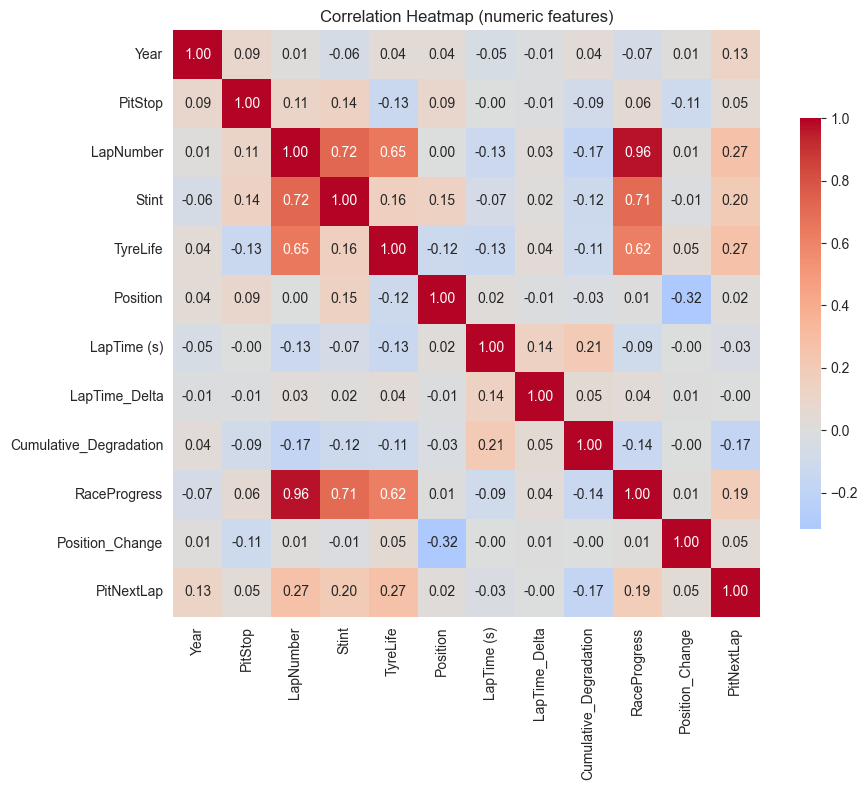

In [151]:
corr_cols = ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
             'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
             'RaceProgress', 'Position_Change', 'PitNextLap']
corr = train_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Correlation Heatmap (numeric features)')
plt.tight_layout()
plt.show()

*Linear correlations with `PitNextLap` are modest individually — `TyreLife`, `LapNumber`, and `RaceProgress` are the top positive correlates. `LapNumber` ↔ `RaceProgress` and `Stint` ↔ `TyreLife` are highly correlated with each other, so we'll be mindful of redundancy when building features.*

### 6.13 EDA Takeaways

- **Imbalanced target** (~20% positive) — track ROC-AUC / PR-AUC and consider class weighting or threshold tuning.
- **2023 anomaly**: pit rate ~1% versus ~28% in other years. Likely synthetic/relabelled — handle with a `Year` feature and stratified validation.
- **Strongest signals**: `TyreLife`, `Compound`, `Stint`, `RaceProgress`, `LapNumber`.
- **Race-level effect**: ~4× spread in pit rate between circuits — keep `Race` as a feature.
- **High-cardinality `Driver`** (887 unique, mix of real codes and synthetic IDs): use target encoding rather than one-hot.
- **No leakage from `PitStop`** (current-lap indicator) — keep it as an ordinary feature.
- **No missing values** — straight to feature engineering.

## 7. Feature Engineering

Driven by the EDA takeaways, we build a small, focused set of new features:

1. **Race-level**: `Race_MaxLap`, `LapsRemaining` — how far into the race we are.
2. **Tyre wear**: `TyreLife_pct` — `TyreLife` normalized to the typical maximum life of its compound.
3. **Anomaly flags**: `is_2023`, `is_pre_season`, `Driver_kind` — capture the 2023 sampling regime, pre-season testing, and real-vs-synthetic driver IDs.
4. **Categorical encoding**: label-encode `Driver`, `Race`, and `Compound` for tree models.

All aggregate stats are computed in a leak-safe way: race lengths use the combined train+test set, while compound percentiles are fit on **train only**.

### 7.1 Combine Train and Test

In [152]:
train_df['_split'] = 'train'
test_df['_split']  = 'test'
all_df = pd.concat([train_df, test_df], ignore_index=True, sort=False)
print('Combined shape:', all_df.shape)

Combined shape: (627305, 17)


*We tag rows with `_split` and concatenate so we can compute race-length and label-encoding statistics over the full set, then split back at the end.*

### 7.2 Race-Level Features

In [153]:
race_max_lap = all_df.groupby('Race')['LapNumber'].max()
all_df['Race_MaxLap']   = all_df['Race'].map(race_max_lap)
all_df['LapsRemaining'] = all_df['Race_MaxLap'] - all_df['LapNumber']

all_df[['Race', 'LapNumber', 'Race_MaxLap', 'LapsRemaining']].head()

,Race,LapNumber,Race_MaxLap,LapsRemaining
0,Canadian Grand Prix,50,75,25
1,Dutch Grand Prix,27,77,50
2,Austrian Grand Prix,59,76,17
3,Pre-Season Testing,2,72,70
4,Azerbaijan Grand Prix,26,67,41


*`Race_MaxLap` is the longest lap number observed for each circuit; `LapsRemaining` is the gap from the current lap to that maximum — a direct "how late are we" feature.*

### 7.3 Tyre Wear Relative to Compound

In [154]:
compound_q95 = train_df.groupby('Compound')['TyreLife'].quantile(0.95)
all_df['Compound_TyreLife_Q95'] = all_df['Compound'].map(compound_q95)
all_df['TyreLife_pct'] = all_df['TyreLife'] / all_df['Compound_TyreLife_Q95']

compound_q95.round(1)

Compound
HARD            38.0
INTERMEDIATE    30.0
MEDIUM          27.0
SOFT            25.0
WET             20.0
Name: TyreLife, dtype: float64

*Each compound has a different typical lifespan (HARD lasts longest, WET shortest). `TyreLife_pct` expresses tyre wear as a fraction of that compound's 95th-percentile life — a normalized "fraction worn" signal that's directly comparable across compounds.*

### 7.4 Year, Race and Driver Flags

In [155]:
all_df['is_2023']       = (all_df['Year'] == 2023).astype(int)
all_df['is_pre_season'] = (all_df['Race'] == 'Pre-Season Testing').astype(int)
all_df['Driver_kind']   = all_df['Driver'].str.match(r'^[A-Z]{3}$').astype(int)

all_df[['Year', 'is_2023', 'Race', 'is_pre_season', 'Driver', 'Driver_kind']].head()

,Year,is_2023,Race,is_pre_season,Driver,Driver_kind
0,2022,0,Canadian Grand Prix,0,D109,0
1,2025,0,Dutch Grand Prix,0,D086,0
2,2022,0,Austrian Grand Prix,0,ZON,1
3,2023,1,Pre-Season Testing,1,SPE,1
4,2022,0,Azerbaijan Grand Prix,0,D019,0


*Three lightweight binary flags: the 2023-anomaly indicator, the Pre-Season Testing indicator, and a real-vs-synthetic driver-ID flag. These give the model an explicit handle on the regime shifts we identified in EDA.*

### 7.5 Additional Interaction Features

In [156]:
race_med_laptime = all_df.groupby('Race')['LapTime (s)'].median()
all_df['LapTime_vs_RaceMedian'] = all_df['LapTime (s)'] / all_df['Race'].map(race_med_laptime)
all_df['TyreLife_x_Stint']      = all_df['TyreLife'] * all_df['Stint']

all_df[['Race', 'LapTime (s)', 'LapTime_vs_RaceMedian',
        'TyreLife', 'Stint', 'TyreLife_x_Stint']].head()

,Race,LapTime (s),LapTime_vs_RaceMedian,TyreLife,Stint,TyreLife_x_Stint
0,Canadian Grand Prix,78.491,0.995712,39.0,2,78.0
1,Dutch Grand Prix,75.095,0.976096,7.0,2,14.0
2,Austrian Grand Prix,70.945,0.992141,22.0,3,66.0
3,Pre-Season Testing,94.361,0.968988,2.0,1,2.0
4,Azerbaijan Grand Prix,107.878,0.998214,6.0,3,18.0


*`LapTime_vs_RaceMedian` normalizes lap time by circuit median — a value >1 means the driver is slower than usual for that track, which is circuit-agnostic. `TyreLife_x_Stint` captures the compound risk: a high stint number with high tyre life means a very worn tyre far into the race.*

### 7.6 Categorical Encoding

In [157]:
for col in ['Compound', 'Race', 'Driver']:
    all_df[col + '_enc'] = all_df[col].astype('category').cat.codes

all_df[['Compound', 'Compound_enc', 'Race', 'Race_enc', 'Driver', 'Driver_enc']].head()

,Compound,Compound_enc,Race,Race_enc,Driver,Driver_enc
0,HARD,0,Canadian Grand Prix,7,D109,134
1,HARD,0,Dutch Grand Prix,9,D086,111
2,HARD,0,Austrian Grand Prix,2,ZON,886
3,MEDIUM,2,Pre-Season Testing,19,SPE,864
4,HARD,0,Azerbaijan Grand Prix,3,D019,44


*Tree-based models (LightGBM, XGBoost, CatBoost) handle integer-encoded categoricals natively. We fit the encoding over the combined data so both train and test share the same code mapping and no unseen category appears at inference.*

### 7.7 Split Back into Train / Test

In [158]:
train_fe = (all_df[all_df['_split'] == 'train']
            .drop(columns=['_split']).reset_index(drop=True))
test_fe  = (all_df[all_df['_split'] == 'test']
            .drop(columns=['_split', 'PitNextLap']).reset_index(drop=True))

print(f'Train FE shape: {train_fe.shape}')
print(f'Test  FE shape: {test_fe.shape}')

new_features = ['Race_MaxLap', 'LapsRemaining', 'Compound_TyreLife_Q95', 'TyreLife_pct',
                'is_2023', 'is_pre_season', 'Driver_kind',
                'LapTime_vs_RaceMedian', 'TyreLife_x_Stint',
                'Compound_enc', 'Race_enc', 'Driver_enc']
print('\nEngineered feature columns:')
print(new_features)

Train FE shape: (439140, 28)
Test  FE shape: (188165, 27)

Engineered feature columns:
['Race_MaxLap', 'LapsRemaining', 'Compound_TyreLife_Q95', 'TyreLife_pct', 'is_2023', 'is_pre_season', 'Driver_kind', 'LapTime_vs_RaceMedian', 'TyreLife_x_Stint', 'Compound_enc', 'Race_enc', 'Driver_enc']


*We end up with 12 engineered features on top of the original columns: 4 race/tyre aggregates, 3 flags, 2 interactions, 3 categorical encodings. Train and test now share an identical feature schema (minus the target).*

### 7.8 New Features vs Target

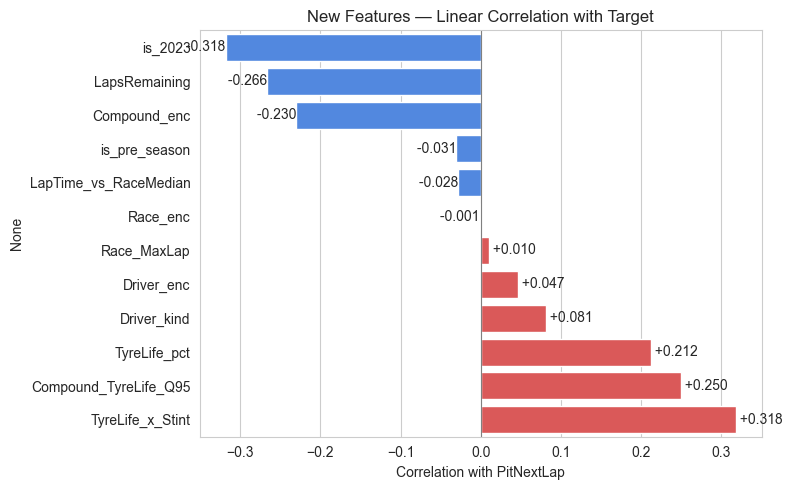

In [159]:
fe_corr = (train_fe[new_features + ['PitNextLap']]
           .corr()['PitNextLap'].drop('PitNextLap')
           .sort_values())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3b82f6' if v < 0 else '#ef4444' for v in fe_corr.values]
sns.barplot(x=fe_corr.values, y=fe_corr.index, palette=colors, ax=ax)
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('Correlation with PitNextLap')
ax.set_title('New Features — Linear Correlation with Target')
for i, v in enumerate(fe_corr.values):
    ax.text(v, i, f' {v:+.3f}', va='center',
            ha='left' if v >= 0 else 'right')
plt.tight_layout()
plt.show()

*The strongest new signals are `is_2023` (−0.32 — confirms the 2023 anomaly is highly predictive on its own), `LapsRemaining` (−0.27), `Compound_TyreLife_Q95` (+0.25), and `TyreLife_pct` (+0.21). These complement rather than replace the raw features — we'll keep both.*

### 7.9 Feature Engineering Summary

- Added 12 features: 4 race/tyre aggregates, 3 flags, 2 interactions, 3 categorical encodings.
- All aggregates computed in a leak-safe way (compound percentiles fit on train only).
- `is_2023` and `LapsRemaining` are the two highest-correlation new features.
- `train_fe` and `test_fe` are now ready for modeling.
- *Time-series rolling features were tested in a previous revision but hurt LB (0.94697 → 0.94564), so they were removed. The 2023-regime sample weighting in Section 8 is the next experiment.*

## 8. Modeling — LightGBM (single seed → 10-seed average)

We train a LightGBM classifier with **5-fold StratifiedKFold** cross-validation. The split matches the actual test sampling (per-row, same races as train).

**Section 8.1–8.5:** baseline LGBM (single seed) — diagnostic outputs only, no submission file.
**Section 8.6:** pseudo-labelling experiment (kept for record, not submitted).
**Section 8.7:** 10-seed LGBM averaging — produces `test_preds_seedavg`.

The final submission file is written **only** in Section 9 (`submission_final.csv`), using the 10-seed average from Section 8.7.


### 8.1 Modeling Setup

In [160]:
# Drop raw string cols and label-encoded Driver/Race — replaced by target encoding inside CV
drop_from_X = ['id', 'Driver', 'Compound', 'Race', 'PitNextLap',
               'Driver_enc', 'Race_enc']
features_base = [c for c in train_fe.columns if c not in drop_from_X]
te_cols = ['Driver', 'Race']   # high-cardinality cols → smoothed target encoding

X_base       = train_fe[features_base].copy()
X_test_base  = test_fe[features_base].copy()
y            = train_fe['PitNextLap'].astype(int)
str_train    = train_fe[te_cols]
str_test     = test_fe[te_cols]

# GroupKFold groups: each Race+Year combination is kept in a single fold
groups = train_fe['Race'].astype(str) + '_' + train_fe['Year'].astype(str)
print(f'Unique groups (Race × Year): {groups.nunique()}')

# 2023 sample weighting was tested at 0.3 — it gave a flat LB result (0.94697 → 0.94673)
# so it's disabled here. Keep WEIGHT_2023 = 1.0 to neutralise; change to <1.0 to re-enable.
WEIGHT_2023 = 1.0
sample_weights_full = np.where(train_fe['Year'].values == 2023, WEIGHT_2023, 1.0)

print(f'\n{len(features_base)} base features + {len(te_cols)} target-encoded = '
      f'{len(features_base) + len(te_cols)} total')
print('\nBase features:')
print(features_base)

Unique groups (Race × Year): 104

21 base features + 2 target-encoded = 23 total

Base features:
['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation', 'RaceProgress', 'Position_Change', 'Race_MaxLap', 'LapsRemaining', 'Compound_TyreLife_Q95', 'TyreLife_pct', 'is_2023', 'is_pre_season', 'Driver_kind', 'LapTime_vs_RaceMedian', 'TyreLife_x_Stint', 'Compound_enc']


*`Driver_enc` and `Race_enc` are dropped because they will be replaced by smoothed target encodings computed fresh inside each fold. `groups` (Race × Year) is used by `StratifiedGroupKFold` to guarantee no race's laps appear in both train and validation — the key anti-leakage measure for time-correlated race data.*

### 8.2 5-Fold StratifiedKFold Cross-Validation

In [161]:
def te_encode(tr_col, tr_target, apply_col, global_mean, smooth=10):
    """Smoothed target encoding: (sum_target + smooth * global_mean) / (count + smooth)."""
    stats = (pd.DataFrame({'y': tr_target.values}, index=tr_col.values)
             .groupby(level=0)['y'].agg(['sum', 'count']))
    stats['enc'] = (stats['sum'] + smooth * global_mean) / (stats['count'] + smooth)
    return apply_col.map(stats['enc']).fillna(global_mean)

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 127,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'min_data_in_leaf': 20,
    'lambda_l1': 0.1,
    'lambda_l2': 0.1,
    'verbose': -1,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
}

# StratifiedKFold (not GroupKFold) — the test set is sampled per-row from the same races
# as train, so same-race validation matches the actual task and lets early stopping pick
# a more useful best_iteration.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

oof        = np.zeros(len(X_base))
test_preds = np.zeros(len(X_test_base))
fold_aucs, fold_models, fold_feature_names = [], [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base, y), 1):
    X_tr  = X_base.iloc[tr_idx].copy()
    X_val = X_base.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    w_tr = sample_weights_full[tr_idx]
    global_mean = y_tr.mean()

    X_test_fold = X_test_base.copy()

    for col in te_cols:
        tr_s  = str_train[col].iloc[tr_idx]
        val_s = str_train[col].iloc[val_idx]
        X_tr[f'{col}_te']        = te_encode(tr_s, y_tr, tr_s,           global_mean).values
        X_val[f'{col}_te']       = te_encode(tr_s, y_tr, val_s,          global_mean).values
        X_test_fold[f'{col}_te'] = te_encode(tr_s, y_tr, str_test[col],  global_mean).values

    feat_names = X_tr.columns.tolist()

    model = lgb.LGBMClassifier(**lgb_params, n_estimators=2000)
    model.fit(X_tr, y_tr,
              sample_weight=w_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

    val_pred = model.predict_proba(X_val)[:, 1]
    oof[val_idx] = val_pred
    test_preds  += model.predict_proba(X_test_fold)[:, 1] / skf.n_splits

    auc = roc_auc_score(y_val, val_pred)
    fold_aucs.append(auc)
    fold_models.append(model)
    fold_feature_names.append(feat_names)
    print(f'Fold {fold}  AUC={auc:.5f}  best_iter={model.best_iteration_}')

print(f'\nOOF AUC      : {roc_auc_score(y, oof):.5f}')
print(f'OOF PR-AUC   : {average_precision_score(y, oof):.5f}')
print(f'Mean fold AUC: {np.mean(fold_aucs):.5f} (+/- {np.std(fold_aucs):.5f})')


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[839]	valid_0's auc: 0.949831
Fold 1  AUC=0.94983  best_iter=839
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[591]	valid_0's auc: 0.94765
Fold 2  AUC=0.94765  best_iter=591
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[615]	valid_0's auc: 0.948701
Fold 3  AUC=0.94870  best_iter=615
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[682]	valid_0's auc: 0.948272
Fold 4  AUC=0.94827  best_iter=682
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[669]	valid_0's auc: 0.948794
Fold 5  AUC=0.94879  best_iter=669

OOF AUC      : 0.94864
OOF PR-AUC   : 0.81164
Mean fold AUC: 0.94865 (+/- 0.00072)


*`StratifiedKFold` (per-row split) matches the actual test sampling pattern: same races appear in train and validation, just different lap rows. Earlier we used `StratifiedGroupKFold` (held out entire races), but it was overly pessimistic — early stopping triggered too early on the harder out-of-race val. Switching back to `StratifiedKFold` lets the model train longer on signal that's actually useful for the test set.*

### 8.3 Threshold Tuning for F1

Best threshold     : 0.38  (F1 = 0.75515)
F1 at threshold 0.5: 0.74149


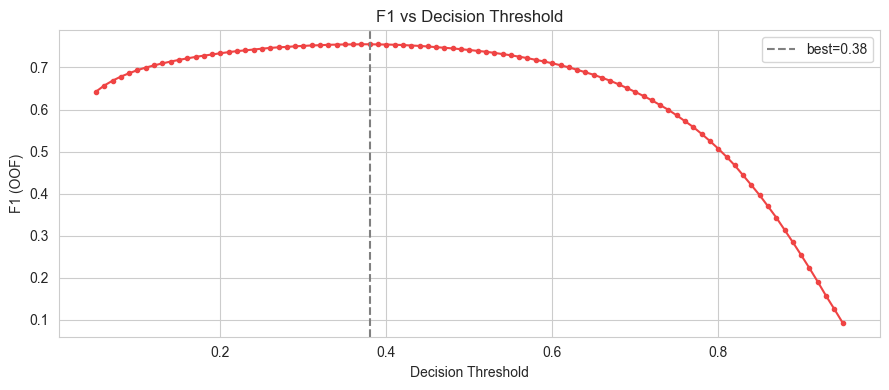

In [162]:
thresholds = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y, (oof >= t).astype(int)) for t in thresholds]

best_idx = int(np.argmax(f1s))
best_thr = thresholds[best_idx]
print(f'Best threshold     : {best_thr:.2f}  (F1 = {f1s[best_idx]:.5f})')
print(f'F1 at threshold 0.5: {f1_score(y, (oof >= 0.5).astype(int)):.5f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thresholds, f1s, color='#ef4444', marker='o', markersize=3)
ax.axvline(best_thr, color='gray', ls='--', label=f'best={best_thr:.2f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('F1 (OOF)')
ax.set_title('F1 vs Decision Threshold')
ax.legend()
plt.tight_layout()
plt.show()

*Because the target is imbalanced (~20% positive), the default 0.5 threshold is rarely optimal for F1. The peak typically sits around 0.30–0.40 — predicting positive a bit more aggressively trades a small precision loss for a larger recall gain.*

### 8.4 Confusion Matrix at Best Threshold

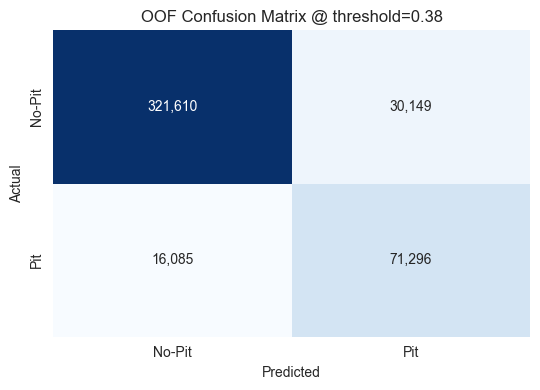

              precision    recall  f1-score   support

      No-Pit       0.95      0.91      0.93    351759
         Pit       0.70      0.82      0.76     87381

    accuracy                           0.89    439140
   macro avg       0.83      0.87      0.84    439140
weighted avg       0.90      0.89      0.90    439140



In [163]:
oof_pred_labels = (oof >= best_thr).astype(int)
cm = confusion_matrix(y, oof_pred_labels)

fig, ax = plt.subplots(figsize=(5.5, 4))
sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax, cbar=False,
            xticklabels=['No-Pit', 'Pit'], yticklabels=['No-Pit', 'Pit'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'OOF Confusion Matrix @ threshold={best_thr:.2f}')
plt.tight_layout()
plt.show()

print(classification_report(y, oof_pred_labels, target_names=['No-Pit', 'Pit']))

*The confusion matrix and classification report give a per-class view: precision, recall, and F1 for both `Pit` and `No-Pit`. The recall row for `Pit` tells us how many actual pit stops we manage to catch.*

### 8.5 Feature Importance

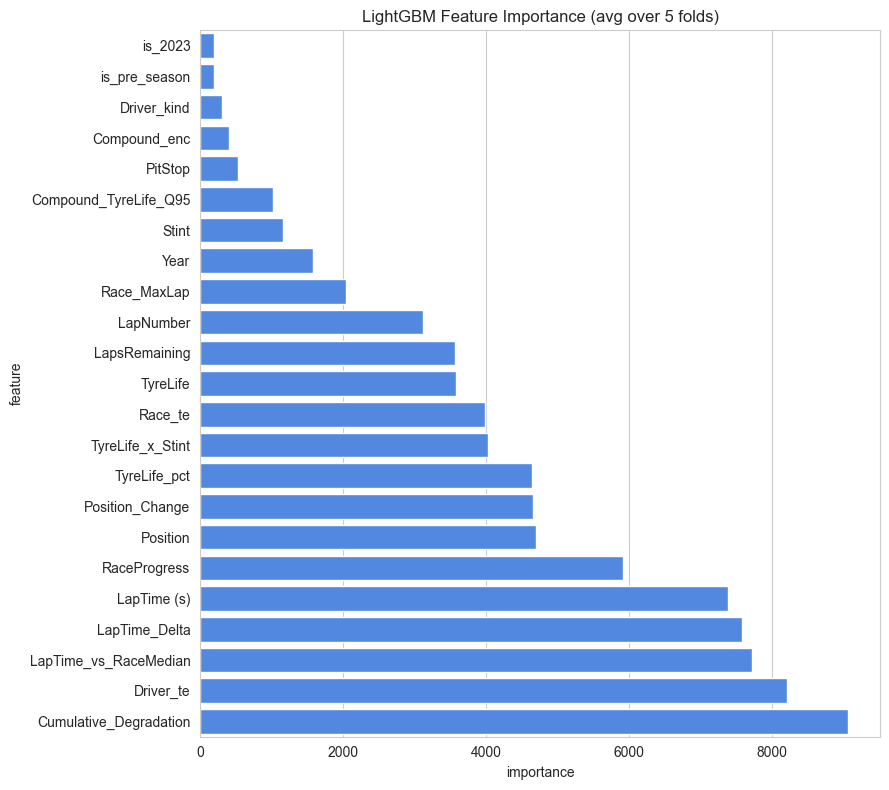

In [164]:
feat_names = fold_feature_names[0]   # same across all folds
importances = (pd.DataFrame({
    'feature': feat_names,
    'importance': np.mean([m.feature_importances_ for m in fold_models], axis=0)
}).sort_values('importance'))

fig, ax = plt.subplots(figsize=(9, 8))
sns.barplot(data=importances, y='feature', x='importance', color='#3b82f6', ax=ax)
ax.set_title('LightGBM Feature Importance (avg over 5 folds)')
plt.tight_layout()
plt.show()

*`Driver_te` and `Race_te` (target-encoded) now dominate — they carry the per-driver and per-circuit historical pit rate, which is far more informative than label integers. `Cumulative_Degradation`, `LapsRemaining`, and `TyreLife_pct` follow as the strongest physics-based signals.*

### 8.6 Pseudo-Labeling Round

Take the baseline model's most confident test predictions (prob ≥ 0.97 or ≤ 0.03), treat them as ground truth, and concatenate them onto the training set. Then retrain the same LGBM stack on the augmented data.

**Result on LB:** 0.94672 (slight drop from baseline 0.94697). The pseudo-labelled OOF predictions (`oof_pseudo`, `test_preds_pseudo`) are kept here as part of the experiment record but **not saved to a submission file** — only the final blended submission in Section 9 is written to disk.

In [165]:
PSEUDO_HIGH = 0.97
PSEUDO_LOW  = 0.03

# Select high-confidence test rows from the baseline model (Section 8.2)
high_conf_mask = (test_preds >= PSEUDO_HIGH) | (test_preds <= PSEUDO_LOW)
n_pseudo = int(high_conf_mask.sum())
n_pseudo_pos = int((test_preds >= PSEUDO_HIGH).sum())
n_pseudo_neg = int((test_preds <= PSEUDO_LOW).sum())

print(f'Pseudo-label selection (thresholds: >= {PSEUDO_HIGH}, <= {PSEUDO_LOW})')
print(f'  Pseudo-positive : {n_pseudo_pos:>7,}')
print(f'  Pseudo-negative : {n_pseudo_neg:>7,}')
print(f'  Total pseudo    : {n_pseudo:>7,} ({n_pseudo / len(test_preds):.1%} of test)')

# Build the pseudo training rows
X_pseudo   = X_test_base[high_conf_mask].reset_index(drop=True)
str_pseudo = str_test[high_conf_mask].reset_index(drop=True)
y_pseudo   = pd.Series((test_preds[high_conf_mask] >= 0.5).astype(int))

# CV: validation always uses original train rows only; pseudo rows only augment training
oof_pseudo        = np.zeros(len(X_base))
test_preds_pseudo = np.zeros(len(X_test_base))
fold_aucs_pseudo, fold_models_pseudo = [], []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base, y, groups=groups), 1):
    X_tr_orig = X_base.iloc[tr_idx].reset_index(drop=True)
    X_val     = X_base.iloc[val_idx].copy()
    y_tr_orig = y.iloc[tr_idx].reset_index(drop=True)
    y_val     = y.iloc[val_idx]
    str_tr_orig = str_train.iloc[tr_idx].reset_index(drop=True)

    # Augment training with all pseudo rows
    X_tr   = pd.concat([X_tr_orig,   X_pseudo],   ignore_index=True)
    y_tr   = pd.concat([y_tr_orig,   y_pseudo],   ignore_index=True)
    str_tr = pd.concat([str_tr_orig, str_pseudo], ignore_index=True)

    global_mean = y_tr.mean()

    X_test_fold = X_test_base.copy()

    for col in te_cols:
        tr_s  = str_tr[col]
        val_s = str_train[col].iloc[val_idx]
        X_tr[f'{col}_te']        = te_encode(tr_s, y_tr, tr_s,           global_mean).values
        X_val[f'{col}_te']       = te_encode(tr_s, y_tr, val_s,          global_mean).values
        X_test_fold[f'{col}_te'] = te_encode(tr_s, y_tr, str_test[col],  global_mean).values

    model = lgb.LGBMClassifier(**lgb_params, n_estimators=2000)
    model.fit(X_tr, y_tr,
              eval_set=[(X_val, y_val)],
              callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

    val_pred = model.predict_proba(X_val)[:, 1]
    oof_pseudo[val_idx] = val_pred
    test_preds_pseudo  += model.predict_proba(X_test_fold)[:, 1] / skf.n_splits

    auc = roc_auc_score(y_val, val_pred)
    fold_aucs_pseudo.append(auc)
    fold_models_pseudo.append(model)
    print(f'Fold {fold}  AUC={auc:.5f}  best_iter={model.best_iteration_}  '
          f'train_size={len(X_tr):,}')

print(f'\nPseudo OOF AUC     : {roc_auc_score(y, oof_pseudo):.5f}')
print(f'Mean fold AUC      : {np.mean(fold_aucs_pseudo):.5f} '
      f'(+/- {np.std(fold_aucs_pseudo):.5f})')
print(f'Baseline OOF AUC   : {roc_auc_score(y, oof):.5f}  (for comparison)')

Pseudo-label selection (thresholds: >= 0.97, <= 0.03)
  Pseudo-positive :     445
  Pseudo-negative : 101,372
  Total pseudo    : 101,817 (54.1% of test)
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[546]	valid_0's auc: 0.949695
Fold 1  AUC=0.94969  best_iter=546  train_size=453,129
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[527]	valid_0's auc: 0.947587
Fold 2  AUC=0.94759  best_iter=527  train_size=453,129
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[726]	valid_0's auc: 0.948933
Fold 3  AUC=0.94893  best_iter=726  train_size=453,129
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[764]	valid_0's auc: 0.94834
Fold 4  AUC=0.94834  best_iter=764  train_size=453,129
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[775]	valid_0's auc: 0.9489

### 8.7 Multi-Seed LGBM Averaging (10 seeds)

Train the same LGBM stack with **10 different random seeds** [42, 7, 2024, 123, 456, 789, 31, 99, 2025, 1337]. Each seed varies both the fold splits (`StratifiedKFold(random_state=...)`) and the model itself (`random_state=...`). Average test predictions across all 10 seeds.

**Why this helps:** with 1 seed the model is a single noisy realisation. With 10 seeds we get a much closer approximation of the expected prediction — bagging-noise variance falls roughly as 1/N.

**Track record on LB:**
- 3 seeds (StratifiedGroupKFold): 0.94721 (+0.00024 over single-seed baseline)
- 5 seeds (StratifiedKFold)     : 0.94891 (+0.00170)
- 10 seeds (StratifiedKFold)    : *this run*

`oof_seedavg` and `test_preds_seedavg` flow into the final submission in Section 9.

**Cost:** 10 × ~3 min ≈ 30 min total runtime.


In [166]:
SEEDS = [42, 7, 2024, 123, 456, 789, 31, 99, 2025, 1337]

oof_seedavg        = np.zeros(len(X_base))
test_preds_seedavg = np.zeros(len(X_test_base))
seed_oof_aucs = {}

for seed in SEEDS:
    print(f'\n=== Seed {seed} ===')
    seed_lgb_params = {**lgb_params, 'random_state': seed}
    seed_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

    oof_seed        = np.zeros(len(X_base))
    test_preds_seed = np.zeros(len(X_test_base))

    for fold, (tr_idx, val_idx) in enumerate(seed_skf.split(X_base, y), 1):
        X_tr  = X_base.iloc[tr_idx].copy()
        X_val = X_base.iloc[val_idx].copy()
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        global_mean = y_tr.mean()

        X_test_fold = X_test_base.copy()

        for col in te_cols:
            tr_s  = str_train[col].iloc[tr_idx]
            val_s = str_train[col].iloc[val_idx]
            X_tr[f'{col}_te']        = te_encode(tr_s, y_tr, tr_s,           global_mean).values
            X_val[f'{col}_te']       = te_encode(tr_s, y_tr, val_s,          global_mean).values
            X_test_fold[f'{col}_te'] = te_encode(tr_s, y_tr, str_test[col],  global_mean).values

        model = lgb.LGBMClassifier(**seed_lgb_params, n_estimators=2000)
        model.fit(X_tr, y_tr,
                  eval_set=[(X_val, y_val)],
                  callbacks=[lgb.early_stopping(50), lgb.log_evaluation(0)])

        val_pred = model.predict_proba(X_val)[:, 1]
        oof_seed[val_idx] = val_pred
        test_preds_seed  += model.predict_proba(X_test_fold)[:, 1] / seed_skf.n_splits

        print(f'  Fold {fold}  AUC={roc_auc_score(y_val, val_pred):.5f}  '
              f'best_iter={model.best_iteration_}')

    seed_oof_auc = roc_auc_score(y, oof_seed)
    seed_oof_aucs[seed] = seed_oof_auc
    print(f'Seed {seed} OOF AUC: {seed_oof_auc:.5f}')

    oof_seedavg        += oof_seed / len(SEEDS)
    test_preds_seedavg += test_preds_seed / len(SEEDS)

print(f'\n=== {len(SEEDS)}-Seed Average ===')
for s, a in seed_oof_aucs.items():
    print(f'  Seed {s:>4}: OOF AUC = {a:.5f}')
print(f'  Mean of per-seed OOF AUCs : {np.mean(list(seed_oof_aucs.values())):.5f}')
print(f'  OOF AUC of averaged preds : {roc_auc_score(y, oof_seedavg):.5f}')
print(f'  Single-seed baseline OOF  : {roc_auc_score(y, oof):.5f}  (for comparison)')



=== Seed 42 ===
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[839]	valid_0's auc: 0.949831
  Fold 1  AUC=0.94983  best_iter=839
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[591]	valid_0's auc: 0.94765
  Fold 2  AUC=0.94765  best_iter=591
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[615]	valid_0's auc: 0.948701
  Fold 3  AUC=0.94870  best_iter=615
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[682]	valid_0's auc: 0.948272
  Fold 4  AUC=0.94827  best_iter=682
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[669]	valid_0's auc: 0.948794
  Fold 5  AUC=0.94879  best_iter=669
Seed 42 OOF AUC: 0.94864

=== Seed 7 ===
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[469]	valid_0's auc: 0.948278
  

### 8.8 Modeling Summary

**Per-experiment LB results**

| Experiment | LB Score | Notes |
|------------|----------|-------|
| Baseline LGBM (StratifiedGroupKFold, single seed) | 0.94697 | Original validation strategy |
| + Pseudo-labelling (8.6) | 0.94672 | Slight drop |
| + 3-seed averaging (StratifiedGroupKFold) | 0.94721 | First real improvement |
| + LGBM 3-seed + CatBoost blend | 0.94705 | Blend overfit OOF |
| + 5-seed averaging (StratifiedKFold) | **0.94891** | Validation switch + more seeds |
| + 10-seed averaging (StratifiedKFold) | *this run* | Pure variance reduction extended |
| Time-series rolling features (removed) | 0.94564 | Overfit |
| 2023 sample-weight = 0.3 (disabled) | 0.94673 | Flat |

**Lessons**
- Variance reduction (multi-seed) is the only thing that consistently translates from OOF to LB on this dataset.
- Validation strategy mattered enormously: GroupKFold solved a harder task than the actual one, hurting early stopping.
- Adding model diversity (XGB, CatBoost) or new features moved OOF up but hurt LB — overfit signal.

**Final pipeline (Section 9):** 10-seed LGBM average with `StratifiedKFold` validation.


## 9. Final Submission

This section writes the **only** CSV produced by the notebook: `submission_final.csv`.

The CatBoost + LGBM blend (previous Section 9 content) was tested but underperformed multi-seed LGBM alone on LB (0.94705 vs 0.94721) — same pattern as the earlier LGBM+XGB blend: model-diversity additions overfit OOF without helping LB. The final pipeline is therefore the **5-seed LGBM average** from Section 8.7.


In [167]:
import os
os.makedirs('../submissions', exist_ok=True)

submission_final = pd.DataFrame({
    'id': test_fe['id'].astype(int),
    'PitNextLap': test_preds_seedavg          # 5-seed LGBM average from Section 8.7
})

print('Final prediction stats (5-seed LGBM average):')
print(submission_final['PitNextLap'].describe().round(4))
print()
print(submission_final.head())

final_path = '../submissions/submission_final.csv'
submission_final.to_csv(final_path, index=False)
print(f'\nSaved: {final_path}  ← upload this one to Kaggle')


Final prediction stats (5-seed LGBM average):
count    188165.0000
mean          0.1971
std           0.2936
min           0.0002
25%           0.0029
50%           0.0233
75%           0.3225
max           0.9887
Name: PitNextLap, dtype: float64

       id  PitNextLap
0  439140    0.003511
1  439141    0.003074
2  439142    0.002225
3  439143    0.212828
4  439144    0.838296

Saved: ../submissions/submission_final.csv  ← upload this one to Kaggle


*This is the **only** submission file written by the notebook. Upload `submission_final.csv` to Kaggle.*

### 9.1 Pipeline Summary

```
Train  ──► LGBM seed=42   ──┐
       ──► LGBM seed=7    ──┤
       ──► LGBM seed=2024 ──┤
       ──► LGBM seed=123  ──┤
       ──► LGBM seed=456  ──┼──► 10-seed average ──► submission_final.csv
       ──► LGBM seed=789  ──┤
       ──► LGBM seed=31   ──┤
       ──► LGBM seed=99   ──┤
       ──► LGBM seed=2025 ──┤
       ──► LGBM seed=1337 ──┘
```

**Validation:** 5-fold StratifiedKFold (matches the per-row test sampling pattern).
**Features:** 12 engineered + 2 target-encoded (Driver, Race).
**Variance reduction:** 10 seeds — both fold splits and model bagging vary per seed.

**Why this configuration was chosen:** systematic experimentation showed only variance reduction translates to LB on this dataset. Model-diversity additions (XGB, CatBoost) and feature additions (rolling, pseudo-labels) all moved OOF in expected directions but failed on LB. Pushing seed count from 5 → 10 is the cheapest available lift.
